In [1]:
import pandas as pd
cbe_df = pd.read_csv('../data/processed/commercial_bank_of_ethiopia_cleaned_reviews.csv')
cbe_df.head()

,review,rating,date,bank,source
0,the app is proactive and a good connections.,5,2025-06-05,Commercial Bank of Ethiopia,Google Play
1,I cannot send to cbebirr app. through this app.,3,2025-06-05,Commercial Bank of Ethiopia,Google Play
2,good,4,2025-06-05,Commercial Bank of Ethiopia,Google Play
3,not functional,1,2025-06-05,Commercial Bank of Ethiopia,Google Play
4,everytime you uninstall the app you have to re...,1,2025-06-04,Commercial Bank of Ethiopia,Google Play


In [2]:
# Number of rows and columns
print("Shape:", cbe_df.shape)

# Column types and non-null counts
print("\nInfo:")
print(cbe_df.info())

# Check for missing values
print("\nMissing values:")
print(cbe_df.isnull().sum())


Shape: (159, 5)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   review  159 non-null    object
 1   rating  159 non-null    int64 
 2   date    159 non-null    object
 3   bank    159 non-null    object
 4   source  159 non-null    object
dtypes: int64(1), object(4)
memory usage: 6.3+ KB
None

Missing values:
review    0
rating    0
date      0
bank      0
source    0
dtype: int64


In [3]:
# Check for duplicates
print("Duplicates:", cbe_df.duplicated().sum())

# Drop duplicates (if any)
cbe_df.drop_duplicates(inplace=True)

# Quick summary of ratings
print("\nRatings summary:")
print(cbe_df['rating'].describe())


Duplicates: 0

Ratings summary:
count    159.000000
mean       3.874214
std        1.641018
min        1.000000
25%        2.500000
50%        5.000000
75%        5.000000
max        5.000000
Name: rating, dtype: float64


Visualize Ratings Distribution

C:\Users\PC\AppData\Local\Temp\ipykernel_11220\1535618868.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=cbe_df, palette='viridis')


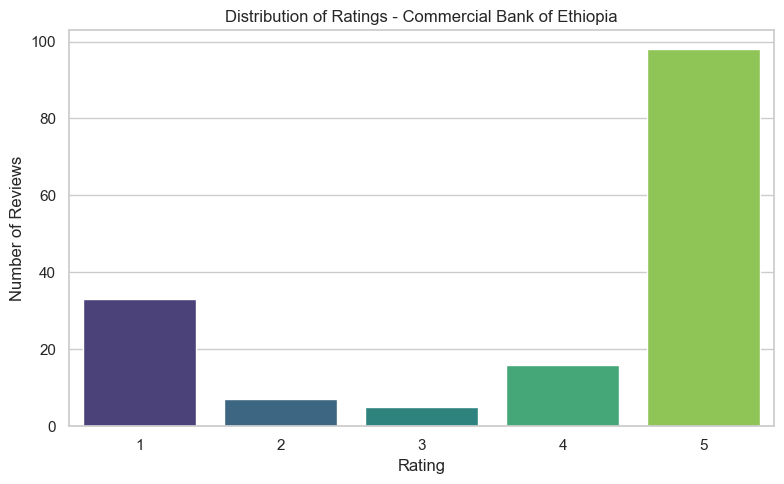

In [7]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style="whitegrid")

# Plot histogram
plt.figure(figsize=(8, 5))
sns.countplot(x='rating', data=cbe_df, palette='viridis')
plt.title('Distribution of Ratings - Commercial Bank of Ethiopia')
plt.xlabel('Rating')
plt.ylabel('Number of Reviews')
plt.tight_layout()
plt.show()


Average Rating Over Time

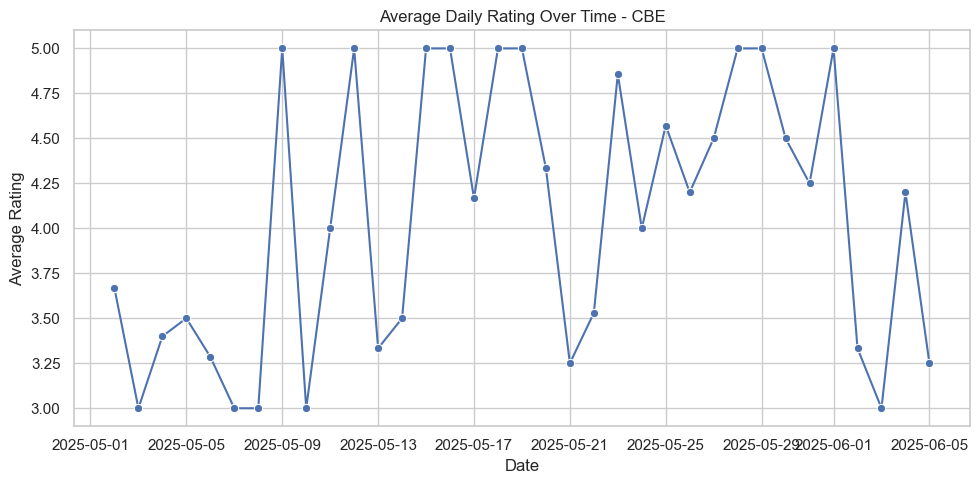

In [8]:
# Convert date column to datetime if not already
cbe_df['date'] = pd.to_datetime(cbe_df['date'])

# Group by date and compute mean rating
daily_avg = cbe_df.groupby('date')['rating'].mean().reset_index()

# Plot the trend
plt.figure(figsize=(10, 5))
sns.lineplot(data=daily_avg, x='date', y='rating', marker='o')
plt.title('Average Daily Rating Over Time - CBE')
plt.xlabel('Date')
plt.ylabel('Average Rating')
plt.tight_layout()
plt.show()


Plot daily Review Counts: This helps reveal how many users left reviews per day (regardless of rating), highlighting spikes or dips in engagement.

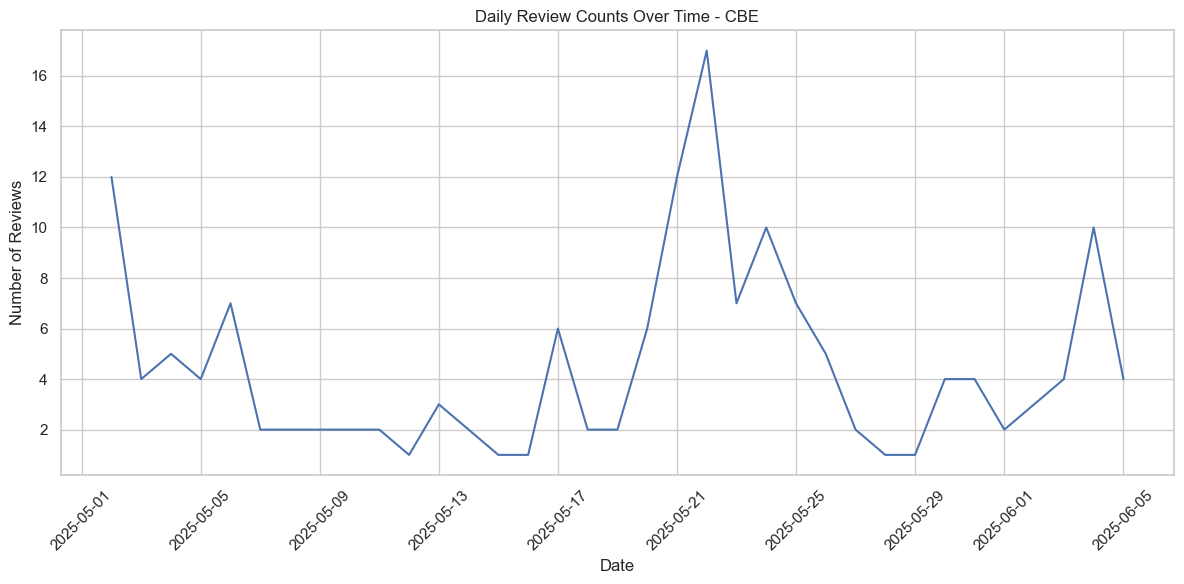

In [11]:
# Group by date and count reviews
daily_review_counts = cbe_df.groupby('date').size()

# Plot daily review counts
plt.figure(figsize=(12, 6))
sns.lineplot(x=daily_review_counts.index, y=daily_review_counts.values)
plt.title('Daily Review Counts Over Time - CBE')
plt.xlabel('Date')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Analyze 1-Star Reviews: isolate 1-star reviews and see what users are complaining about.